In [1]:
import numpy as np
from scipy.optimize import linprog

def cvar_frontier_linprog(returns, alpha, target_returns):
    """
    Compute CVaR efficient frontier using linear programming (SciPy HiGHS).

    returns: (T, N) scenario return matrix
    alpha: CVaR confidence level (e.g. 0.95)
    target_returns: iterable of target expected returns
    """

    T, N = returns.shape
    mu = returns.mean(axis=0)

    frontier = []

    # Variable layout: [w_1 ... w_N | t | z_1 ... z_T]
    n_vars = N + 1 + T

    # Objective coefficients
    c = np.zeros(n_vars)
    c[N] = 1.0                                  # t
    c[N+1:] = 1.0 / ((1 - alpha) * T)           # z_j

    # Bounds
    bounds = [(0, None)] * N                    # w >= 0
    bounds += [(None, None)]                    # t free
    bounds += [(0, None)] * T                   # z >= 0

    for mu_target in target_returns:

        A_eq = []
        b_eq = []

        # sum(w) = 1
        row = np.zeros(n_vars)
        row[:N] = 1.0
        A_eq.append(row)
        b_eq.append(1.0)

        A_ub = []
        b_ub = []

        # Expected return constraint: -mu^T w <= -mu_target
        row = np.zeros(n_vars)
        row[:N] = -mu
        A_ub.append(row)
        b_ub.append(-mu_target)

        # CVaR constraints: -R_j w - t - z_j <= 0
        for j in range(T):
            row = np.zeros(n_vars)
            row[:N] = -returns[j]
            row[N] = -1.0                      # t
            row[N + 1 + j] = -1.0              # z_j
            A_ub.append(row)
            b_ub.append(0.0)

        result = linprog(
            c=c,
            A_ub=np.array(A_ub),
            b_ub=np.array(b_ub),
            A_eq=np.array(A_eq),
            b_eq=np.array(b_eq),
            bounds=bounds,
            method="highs"
        )

        if not result.success:
            raise RuntimeError(result.message)

        w_opt = result.x[:N]
        cvar_val = result.fun

        frontier.append({
            "target_return": mu_target,
            "cvar": cvar_val,
            "weights": w_opt
        })

    return frontier


In [2]:
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
from math import log

companies, tickers = ['Honeywell','Salesforce','Meta','Apple','Google'],['HON','CRM','META','AAPL','GOOGL']

tickers_df = yf.download(tickers, 
                      start='2020-01-01', 
                      end='2026-02-01', 
                      progress=False, auto_adjust=True)
display(tickers_df.head(2))
display(tickers_df.tail(2))

# returns = tickers_df['Close'].applymap(log).diff()[1:]
# returns = tickers_df['Close'].map(log).diff()[1:]

returns = tickers_df['Close'].map(log).diff()[1:].to_numpy()

Price           Close                                                 \
Ticker           AAPL         CRM      GOOGL         HON        META   
Date                                                                   
2020-01-02  72.400513  164.985397  67.920815  150.367004  208.324768   
2020-01-03  71.696640  164.175247  67.565483  148.761749  207.222488   

Price            High                                                 ...  \
Ticker           AAPL         CRM      GOOGL         HON        META  ...   
Date                                                                  ...   
2020-01-02  72.460776  165.064439  67.920815  150.375312  208.334693  ...   
2020-01-03  72.455958  164.768051  68.172401  149.568518  208.940483  ...   

Price            Open                                                 \
Ticker           AAPL         CRM      GOOGL         HON        META   
Date                                                                   
2020-01-02  71.409778  161.952243  66.914918  147.630629  205.315788   
2020-01-03  71.629145  163.078571  66.894558  148.329260  205.772625   

Price          Volume                                        
Ticker           AAPL      CRM     GOOGL      HON      META  
Date                                                         
2020-01-02  135480400  5189300  27278000  3031701  12077100  
2020-01-03  146322800  3205400  23408000  2976317  11188400  

[2 rows x 25 columns]

Price            Close                                              \
Ticker            AAPL         CRM   GOOGL         HON        META   
Date                                                                 
2026-01-29  258.038544  214.080002  338.25  227.240005  738.309998   
2026-01-30  259.237427  212.289993  338.00  227.520004  716.500000   

Price             High                                                  ...  \
Ticker            AAPL         CRM       GOOGL         HON        META  ...   
Date                                                                    ...   
2026-01-29  259.407258  217.279999  342.290009  227.860001  744.000000  ...   
2026-01-30  261.655147  215.550003  340.000000  229.589996  732.169983  ...   

Price             Open                                                  \
Ticker            AAPL         CRM       GOOGL         HON        META   
Date                                                                     
2026-01-29  257.758807  216.669998  340.299988  221.240005  737.429993   
2026-01-30  254.931443  214.160004  340.000000  226.740005  727.500000   

Price         Volume                                         
Ticker          AAPL       CRM     GOOGL      HON      META  
Date                                                         
2026-01-29  67253000  18555600  39785600  6945200  59852900  
2026-01-30  92443400  11090400  31024000  6719200  23744600  

[2 rows x 25 columns]

In [3]:
target_returns = np.linspace(
    returns.mean(axis=0).min(),
    returns.mean(axis=0).max(),
    20
)

frontier = cvar_frontier_linprog(
    returns=returns,
    alpha=0.95,
    target_returns=target_returns
)

In [4]:
def cvar_per_asset_safe(returns, alpha=0.95):
    losses = -returns
    T, N = losses.shape

    cvar = np.zeros(N)

    for i in range(N):
        li = losses[:, i]
        var_i = np.quantile(li, alpha)
        tail = li[li >= var_i]
        cvar[i] = tail.mean()

    return cvar


In [5]:
stock_returns = returns.mean(axis=0)
stock_cvar = cvar_per_asset_safe(returns)

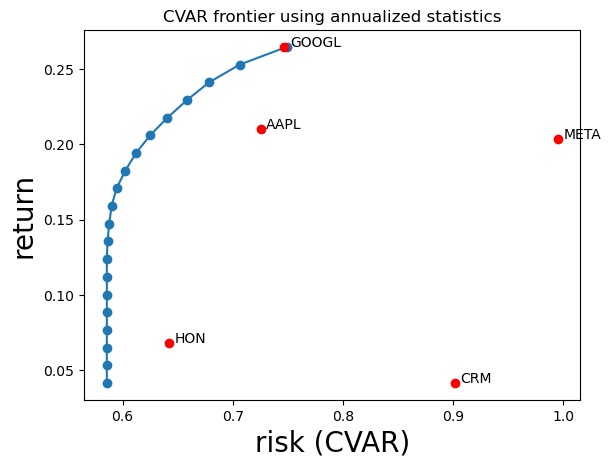

In [6]:
import matplotlib.pyplot as plt

cvar_returns = [f['target_return'] for f in  frontier]
cvar_cvar = [f['cvar'] for f in  frontier]
cvar_weights = np.array([f['weights'] for f in  frontier])

plt.plot(np.array(cvar_cvar) * np.sqrt(252), np.array(cvar_returns) * 252, 'o-')

for n, r, s in zip(tickers_df['Close'].columns, stock_returns *252, stock_cvar * np.sqrt(252)):
    plt.plot([s], [r], 'o', color='red')
    plt.text(s+0.005, r, n)

plt.title('CVAR frontier using annualized statistics')
plt.xlabel('risk (CVAR)', fontsize=20)
plt.ylabel('return', fontsize=20)
plt.show()

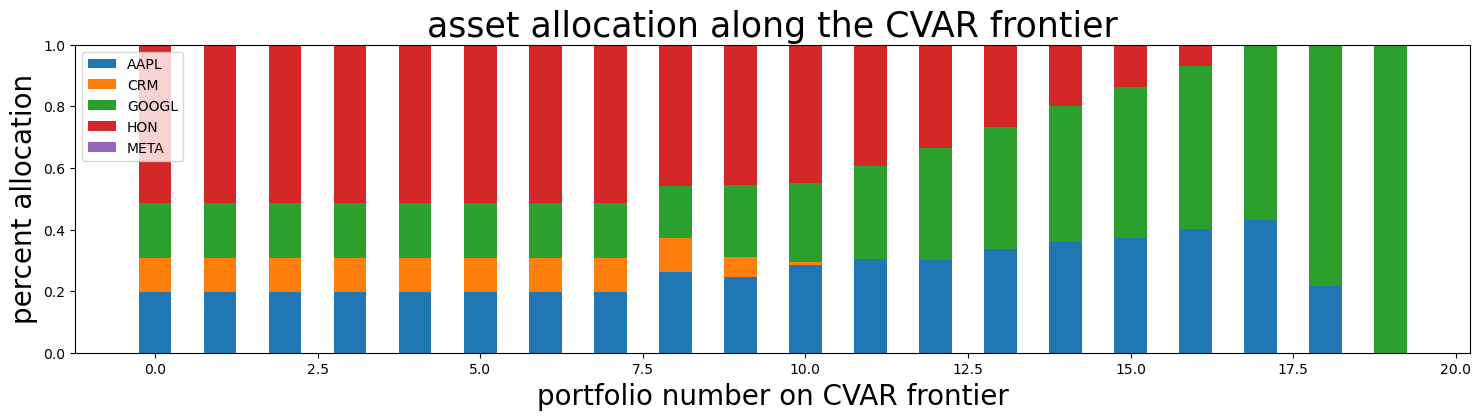

In [7]:
plt.figure(figsize=(18,4))
ind, width = range(len(cvar_weights)), .5  # number of portfolios, the width of each bar in the plot

cumulative = [0.] * cvar_weights.shape[0]
for i,t in enumerate(cvar_weights.T):
    plt.bar(ind, cvar_weights.T[i], width, bottom=cumulative, label=tickers_df['Close'].columns[i])
    cumulative += t

plt.legend(loc='upper left')
plt.title("asset allocation along the CVAR frontier", fontsize=25)
plt.ylabel("percent allocation", fontsize=20)
plt.xlabel("portfolio number on CVAR frontier", fontsize=20)
plt.show()